In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data

In [2]:
with open('all_results.json', 'r') as f:
    all_results = json.load(f)

ens_summary = pd.read_csv("summary.csv")

In [3]:
all_results.keys()

dict_keys(['dl_1_trained_models', 'stage_1', 'stage_2_stepLR', 'stage_2_CosineAnnealingLR', 'stage_2_LR_0.0003', 'stage_2_LR_0.003', 'stage_2_MultiStepLR', 'stage_3_wd_0.2_dr_0.0001', 'stage_3_dropout', 'stage_3_mix_soft', 'stage_3_mix_hard', 'stage_3_wd', 'stage_4_mix_soft_aug', 'stage_4_mix_hard_aug', 'stage_4_mix_hard_cut', 'stage_4_mix_soft_cut', 'stage_4_mix_hard_aug_cut_grad_accumulation', 'stage_4_mix_soft_aug_cut', 'stage_5_1__10_percent', 'stage_5_2__10_percent_aug', 'stage_5_1__1_percent', 'stage_5_1__50_per_class', 'stage_5_2__1_percent_aug', 'stage_5_2__50_per_class_aug', 'stage_5_1__20_per_class', 'stage_5_2__20_per_class_aug', 'stage_5_3__1_percent_reg', 'stage_5_3__20_per_class_reg', 'stage_5_4__pre_10_percent_0.0003', 'stage_5_4__pre_1_percent_0.0003', 'stage_5_4__pre_50_per_class_0.0003', 'stage_5_4__pre_20_per_class_0.0003', 'stage_5_3__10_percent_reg', 'stage_5_3__50_per_class_reg'])

In [6]:
all_results.pop('dl_1_trained_models', None)

{}

In [7]:
all_results.keys()

dict_keys(['stage_1', 'stage_2_stepLR', 'stage_2_CosineAnnealingLR', 'stage_2_LR_0.0003', 'stage_2_LR_0.003', 'stage_2_MultiStepLR', 'stage_3_wd_0.2_dr_0.0001', 'stage_3_dropout', 'stage_3_mix_soft', 'stage_3_mix_hard', 'stage_3_wd', 'stage_4_mix_soft_aug', 'stage_4_mix_hard_aug', 'stage_4_mix_hard_cut', 'stage_4_mix_soft_cut', 'stage_4_mix_hard_aug_cut_grad_accumulation', 'stage_4_mix_soft_aug_cut', 'stage_5_1__10_percent', 'stage_5_2__10_percent_aug', 'stage_5_1__1_percent', 'stage_5_1__50_per_class', 'stage_5_2__1_percent_aug', 'stage_5_2__50_per_class_aug', 'stage_5_1__20_per_class', 'stage_5_2__20_per_class_aug', 'stage_5_3__1_percent_reg', 'stage_5_3__20_per_class_reg', 'stage_5_4__pre_10_percent_0.0003', 'stage_5_4__pre_1_percent_0.0003', 'stage_5_4__pre_50_per_class_0.0003', 'stage_5_4__pre_20_per_class_0.0003', 'stage_5_3__10_percent_reg', 'stage_5_3__50_per_class_reg'])

# stage 1

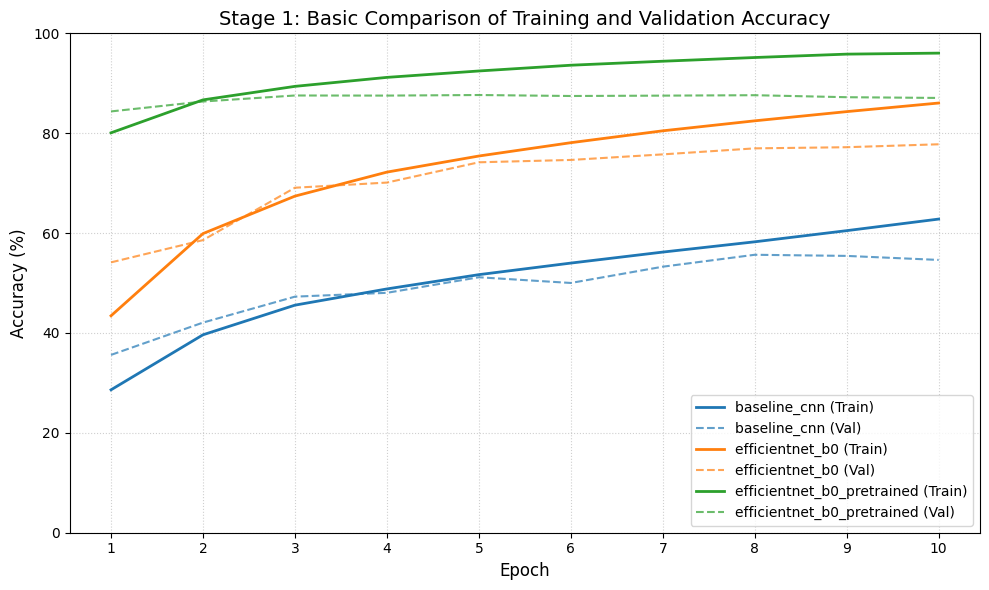

In [12]:
plt.figure(figsize=(10, 6))

stage_1_models = all_results.get("stage_1", {})

# Lista kolorów, aby modele się odróżniały
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (model_name, data) in enumerate(stage_1_models.items()):
    history = data.get("history", {})
    epochs = history.get("epoch", [])
    train_acc = history.get("train_acc", [])
    val_acc = history.get("val_acc", []) # Jeśli masz dane walidacyjne
    
    color = colors[i % len(colors)]
    
    # Rysujemy linię treningu (ciągła)
    plt.plot(epochs, train_acc, label=f'{model_name} (Train)', 
                linestyle='-', color=color, linewidth=2)
    
    # Rysujemy linię walidacji (przerywana), jeśli istnieje
    if val_acc:
        plt.plot(epochs, val_acc, label=f'{model_name} (Val)', 
                    linestyle='--', color=color, alpha=0.7)

plt.title('Stage 1: Basic Comparison of Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(range(1, 11)) # Zakładając 10 epok
plt.ylim(0, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('report_images/stage_1_comparison.png')
plt.show()